<a href="https://colab.research.google.com/github/Jennymgm/Cartografia-multivariada-/blob/main/Lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA introductorio (no espacial) — Airbnb Lisboa, Portugal

**Objetivo del notebook:** aplicar una lógica **exploratoria** antes de cartografiar o modelar:
1) entender el *esquema* y el tipo de variables,  
2) diagnosticar calidad de datos (nulos, extremos, valores raros),  
3) generar un *dataset limpio* y documentado para el paso ESDA (espacial) posterior.

[Airbnb - Get the Data](https://insideairbnb.com/get-the-data/)




# 1. Carga y reconocimiento inicial del dataset 📉

En cualquier Análisis Exploratorio de Datos (EDA), el primer paso no es graficar ni limpiar, sino **entender qué tenemos en las manos**.

En esta sección realizamos tres acciones básicas pero fundamentales:

### 1️⃣ `df.shape` y `df.columns`
- `df.shape` nos indica la dimensión del dataset: número de filas (observaciones) y columnas (variables).
- `df.columns` permite conocer los nombres de las variables disponibles.
  
Esto nos ayuda a responder:
- ¿Cuántos registros hay?
- ¿Cuántas variables tenemos para analizar?
- ¿Qué tipo de información parece contener cada columna?

---

In [ ]:
# ============================================
# Preparación del entorno para Google Colab
#============================================

!pip -q install pandas numpy matplotlib requests

import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


raw_url = "https://raw.githubusercontent.com/Jennymgm/Cartografia-multivariada-/refs/heads/main/listings.csv"

df = pd.read_csv(raw_url)
print("Datos cargados desde raw_url.")

Datos cargados desde raw_url.


## Version en Local

In [ ]:
# Cargar librerías
# Es importante tener las librerias ya instaladas
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt

# Ajustes visuales básicos
##plt.rcParams['figure.dpi'] = 120
#plt.rcParams['axes.grid'] = False

# Ruta del archivo (ya montado en el entorno) Mint
#csv_path = r"/media/estb/Cris_volcano_2/Curso_cartografia_Multivariada/Datos/Airbnb/Ejemplo_Lisboa.csv"
#POP
#csv_path = r"/home/crisvolcano/Documents/Curso_Multivariada/Laboratorio_1/Ejemplo_Lisboa.csv"

#df = pd.read_csv(csv_path)

#df.shape, df.columns

### 1.1) Lectura rápida del dataset

In [ ]:
df.head(2)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,2384,Hyde Park - Walk to University of Chicago,2613,Rebecca,NaN,Hyde Park,41.78790,-87.58780,Private room,119.0,3,257,2025-08-07,1.97,1,348,10,R17000015609
1,7126,Tiny Studio Apartment 94 Walk Score,17928,Sarah,NaN,West Town,41.90166,-87.68021,Entire home/apt,89.0,2,595,2025-09-01,3.01,1,302,47,R24000114046


In [ ]:
# Que tipo de dato tiene cada columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8663 entries, 0 to 8662
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              8663 non-null   int64  
 1   name                            8663 non-null   object 
 2   host_id                         8663 non-null   int64  
 3   host_name                       8042 non-null   object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   8663 non-null   object 
 6   latitude                        8663 non-null   float64
 7   longitude                       8663 non-null   float64
 8   room_type                       8663 non-null   object 
 9   price                           7828 non-null   float64
 10  minimum_nights                  8663 non-null   int64  
 11  number_of_reviews               8663 non-null   int64  
 12  last_review                     69

# 2) Tipos de variables y “rol” analítico

Lo primero  que debemos hacer es entender nuestra base de datos:
- **Identificadores:** `id`, `host_id` (no se usan para estadística descriptiva “de valor”, pero son fundamentales).
- **Texto:** `name`, `host_name` (útil para calidad de datos, pero no para modelar directo).
- **Categóricas:** `neighbourhood_group`, `neighbourhood`, `room_type`, `license` (esta última puede tratarse como texto/categórica).
- **Numéricas:** `price`, `minimum_nights`, `number_of_reviews`, `reviews_per_month`,
  `calculated_host_listings_count`, `availability_365`, `number_of_reviews_ltm`.
- **Temporal:** `last_review` (nos habla de fechas).
- **Espaciales (para ESDA posterior):** `latitude`, `longitude`.


In [ ]:
# Tipos de dato detectados por pandas
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,float64
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,float64


## 2.1 Agrupemos las columnas por temáticas

In [ ]:
# Listas de columnas por “rol”
id_cols = ['id', 'host_id']
text_cols = ['name', 'host_name', 'license']
cat_cols = ['neighbourhood_group', 'neighbourhood', 'room_type']
num_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
            'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm']
date_cols = ['last_review']
spatial_cols = ['latitude', 'longitude']

{
    "id_cols": id_cols,
    "text_cols": text_cols,
    "cat_cols": cat_cols,
    "num_cols": num_cols,
    "date_cols": date_cols,
    "spatial_cols": spatial_cols
}

{'id_cols': ['id', 'host_id'],
 'text_cols': ['name', 'host_name', 'license'],
 'cat_cols': ['neighbourhood_group', 'neighbourhood', 'room_type'],
 'num_cols': ['price',
  'minimum_nights',
  'number_of_reviews',
  'reviews_per_month',
  'calculated_host_listings_count',
  'availability_365',
  'number_of_reviews_ltm'],
 'date_cols': ['last_review'],
 'spatial_cols': ['latitude', 'longitude']}

# 3) Calidad de datos: nulos, duplicados, valores “raros”

Muchas veces al trabajar con datos omitimos el diagnóstico rápido y simplemente pasamos al “mapear ya”.

Es importante analizar:

- ¿Qué variables tienen valores faltantes?
- ¿Los nulos son estructurales o problemáticos?
- ¿Debemos imputar, eliminar o ignorar?


## 3.1 Hay nulos en nuestras columnas

In [ ]:
# Nulos por columna
na = df.isna().sum().sort_values(ascending=False)
na[na>0]

,0
neighbourhood_group,8663
license,2880
reviews_per_month,1685
last_review,1685
price,835
host_name,621


*¿Qué ven en los resultados?*

## 3.1 Hay duplicados en las filas

In [ ]:
# Duplicados (fila completa) y duplicados por id
dup_rows = df.duplicated().sum()
dup_id = df['id'].duplicated().sum()

print("Diagnóstico de duplicados:\n")

# Filas completas duplicadas
if dup_rows == 0:
    print("✔ La base de datos NO tiene filas completamente duplicadas.")
else:
    print(f"⚠ La base de datos tiene {dup_rows} filas completamente duplicadas.")

# Duplicados por identificador
if dup_id == 0:
    print("✔ No existen identificadores (id) duplicados.")
else:
    print(f"⚠ Existen {dup_id} identificadores duplicados.")

Diagnóstico de duplicados:

✔ La base de datos NO tiene filas completamente duplicadas.
✔ No existen identificadores (id) duplicados.


# 4) Limpieza mínima y variables derivadas

## 4.1 Parseo de fechas
Algunas bases de datos tienen columnas que están asociadas a fechas, en cualquier software de análisis (QGIS, ARCGIS, R, etc) debemos asegurarnos que estás sean interpretadas en este formato. De lo contrario es complejo realizar análisis temporales.

A modo de ejemplo:
Convertimos `last_review` a datetime (y dejamos NA donde corresponda).




In [ ]:
# Convertir 'last_review' a formato datetime
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

# Verificación
print("Tipo de dato actual de 'last_review':", df['last_review'].dtype)
print("Cantidad de fechas válidas:", df['last_review'].notna().sum())
print("Cantidad de fechas no válidas (NaT):", df['last_review'].isna().sum())

Tipo de dato actual de 'last_review': datetime64[ns]
Cantidad de fechas válidas: 6978
Cantidad de fechas no válidas (NaT): 1685


## 4.2 Depuración del dataset

Supongamos que nuestra variable principal de análisis es el **precio**.  
Antes de calcular estadísticas, graficar distribuciones o construir mapas, debemos hacer una pregunta básica pero fundamental:

> “Si quiero analizar precios, ¿tiene sentido incluir registros que no tienen precio?”

La respuesta es no -en este ejemplo-.

El diagnóstico previo de valores faltantes nos mostró que existen **3579 observaciones sin información de precio**.  
Estas observaciones no pueden participar en:

- Cálculo de medias o medianas.
- Análisis de dispersión.
- Modelos explicativos del precio.
- Representaciones cartográficas del valor económico.

Por lo tanto, definimos un **subconjunto analítico** que incluye únicamente los registros con precio disponible.

Es importante aclarar que:

- No estamos eliminando datos del dataset original.
- Estamos definiendo el universo válido para esta pregunta específica.
- Los registros sin precio podrían ser útiles para otros análisis.

Este paso representa una decisión metodológica explícita:  
el universo de análisis depende de la variable de interés.

Creamos `df_work = df[df.price.notna()]` para análisis de precio.



In [ ]:
#Eliminar valores nulos de precio
df_work = df[df.price.notna()]

# Verificación: confirmar que no existen valores nulos en 'price'
null_price_count = df_work['price'].isna().sum()

if null_price_count == 0:
    print("✔ Verificación correcta: no existen valores nulos en la columna 'price'.")
else:
    print(f"⚠ Aún existen {null_price_count} valores nulos en 'price'.")

✔ Verificación correcta: no existen valores nulos en la columna 'price'.


## 4.3 Tratamiento exploratorio de valores extremos (outliers)

Hasta este punto hemos definido el subconjunto válido para analizar precios.  
Ahora surge una pregunta fundamental:

¿El comportamiento observado en la distribución del precio refleja la estructura real del mercado o está condicionado por unos pocos valores extremadamente altos?

Las bases de datos reales —especialmente en fenómenos económicos— suelen presentar valores atípicos.  
Sin embargo, es importante comprender que:

- Un valor extremo no necesariamente es un error.
- Puede representar un segmento específico del mercado (por ejemplo, alojamientos de lujo).
- Puede responder a dinámicas distintas dentro del mismo fenómeno.

Por esta razón, antes de tomar decisiones como eliminar, transformar o truncar datos, debemos:

1. Visualizar la distribución original.
2. Identificar la magnitud de la asimetría.
3. Evaluar el peso relativo de los valores extremos.

El objetivo de este análisis no es eliminar información, sino entender cómo la presencia de valores muy altos afecta la interpretación estadística y visual del comportamiento general del precio.


Los **histogramas y los diagramas de cajas**  son útiles para este tipo de análisis

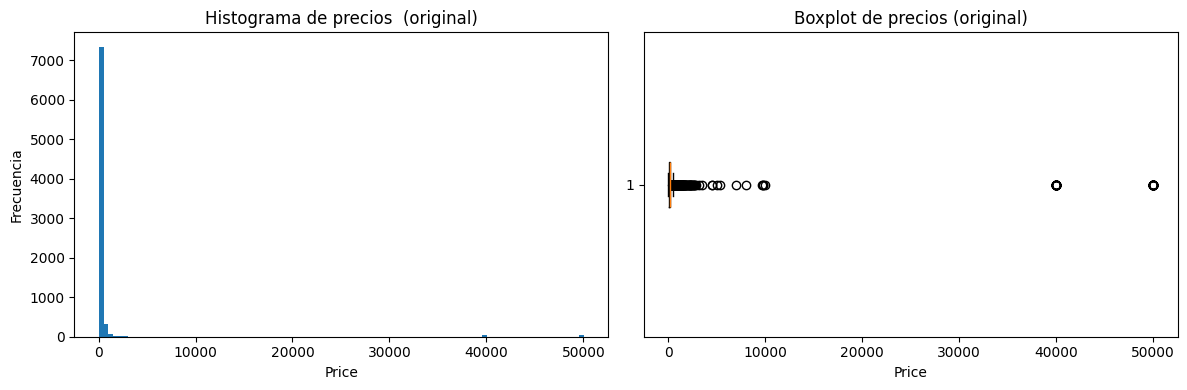

Precio mínimo: 13.0
Precio máximo: 50032.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma (datos crudos)
axes[0].hist(df_work['price'], bins=100)
axes[0].set_title("Histograma de precios  (original)")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frecuencia")

# Boxplot (datos crudos)
axes[1].boxplot(df_work['price'], vert=False)
axes[1].set_title("Boxplot de precios (original)")
axes[1].set_xlabel("Price")

plt.tight_layout()
plt.show()

print("Precio mínimo:", df_work['price'].min())
print("Precio máximo:", df_work['price'].max())

## Reflexión exploratoria

Observando el histograma y el boxplot de los precios en su escala original, surgen algunas preguntas:

- ¿Podemos realmente interpretar cómo se distribuyen los precios?
- ¿Se distingue claramente el comportamiento típico del mercado?
- ¿Qué efecto tienen los valores extremadamente altos en la visualización?
- ¿La media sería una buena medida representativa en este caso?
- ¿Este gráfico nos ayuda a comprender el mercado o lo distorsiona?

A simple vista, el histograma parece "aplastado" hacia la izquierda, mientras que el boxplot muestra una gran cantidad de valores extremos muy alejados del núcleo principal.

Esto nos lleva a una pregunta metodológica clave:

> ¿Estamos viendo la estructura real del mercado o estamos viendo el efecto de unos pocos valores extremadamente altos?


### 4.3.1 Transformaciones para mejorar la interpretación

El análisis visual de la distribución original del precio mostró una asimetría positiva muy marcada y la presencia de valores extremadamente altos.

Cuando una distribución presenta una cola larga hacia la derecha, pueden ocurrir varios efectos:

- La media se ve fuertemente influenciada.
- La escala de los gráficos se distorsiona.
- El comportamiento dominante de los datos queda “aplastado”.
- La interpretación visual se vuelve poco informativa.

En estos casos, no buscamos eliminar información, sino aplicar transformaciones que permitan:

1. Visualizar mejor la estructura real del fenómeno.
2. Reducir la influencia desproporcionada de los valores extremos.
3. Comparar el comportamiento típico frente al comportamiento extremo.

Aplicaremos dos estrategias exploratorias:

- Transformación logarítmica del precio (para analizar la forma de la distribución).
- Truncamiento superior basado en percentiles (capping) para análisis descriptivo más estable.

Es importante enfatizar que:
- Estas transformaciones no reemplazan los datos originales.
- Se utilizan con fines exploratorios e interpretativos.
- Siempre deben justificarse en función del fenómeno estudiado, **en este caso son funcionales por el fenómeno**.

In [ ]:
# ============================================
# Transformación logarítmica del precio
# ============================================

# Evitamos problemas con log(0) usando clip(lower=1)
df_work['price_log10'] = np.log10(df_work['price'].clip(lower=1))

print("Nueva variable creada: 'price_log10'")
print("Resumen estadístico:")
display(df_work['price_log10'].describe())

Nueva variable creada: 'price_log10'
Resumen estadístico:


/tmp/ipykernel_30038/2450666662.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_work['price_log10'] = np.log10(df_work['price'].clip(lower=1))


,price_log10
count,7828.000000
mean,2.204555
std,0.400063
min,1.113943
25%,1.986772
50%,2.184691
75%,2.380211
max,4.699248


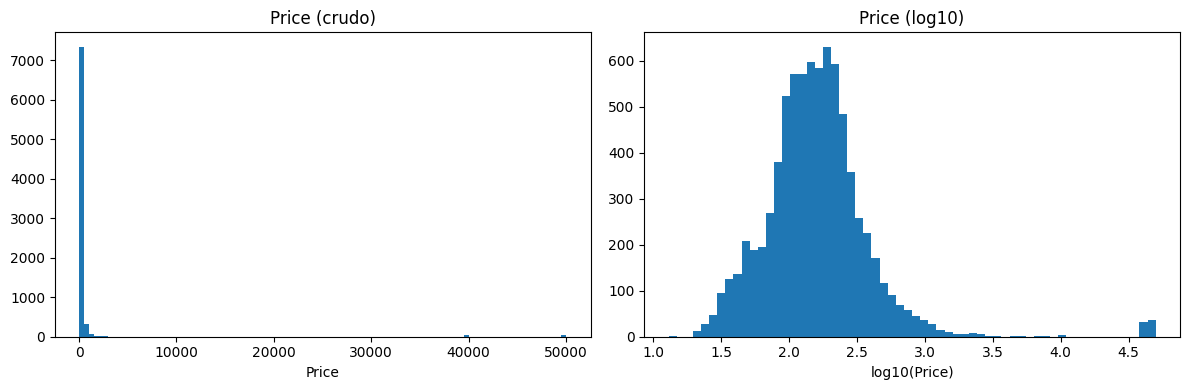

In [ ]:
# ============================================
# Comparación visual: Price crudo vs Log
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma original
axes[0].hist(df_work['price'], bins=100)
axes[0].set_title("Price (crudo)")
axes[0].set_xlabel("Price")

# Histograma log
axes[1].hist(df_work['price_log10'], bins=60)
axes[1].set_title("Price (log10)")
axes[1].set_xlabel("log10(Price)")

plt.tight_layout()
plt.show()

Al comparar el histograma original del precio con su versión transformada (log10), observamos un cambio importante en la forma de la distribución.

### En la escala original:

- La mayoría de los valores se concentran en precios bajos.
- Existen valores extremadamente altos que estiran la escala.
- La distribución presenta una fuerte asimetría positiva.
- El comportamiento típico del mercado queda visualmente comprimido.

### En la escala logarítmica:

- Los valores altos se comprimen.
- La distribución se vuelve más simétrica.
- Se distingue mejor la estructura dominante de los datos.
- La variabilidad relativa se interpreta con mayor claridad.

La transformación logarítmica no elimina información ni corrige errores.  
Su objetivo es mejorar la capacidad **interpretativa** cuando los datos presentan colas largas o alta asimetría.

En términos exploratorios, buscamos responder:

- ¿La asimetría es estructural del fenómeno?
- ¿Las medidas como la media representan adecuadamente el mercado?
- ¿Es necesario trabajar con transformaciones en análisis posteriores?

Esta comparación nos permite entender mejor la naturaleza estadística del precio antes de aplicar decisiones como truncamientos o modelado.

### 4.3.2 Utilizar el percentil 99

El análisis visual del precio mostró una distribución **fuertemente asimétrica**, con una cola larga hacia la derecha y la presencia de valores extremadamente altos.

En este contexto, utilizar únicamente el valor máximo como referencia no es adecuado, ya que el máximo puede representar un caso excepcional y no el comportamiento estructural del mercado.

El percentil 99 nos permite establecer un umbral más representativo, respondiendo a la pregunta:

> ¿Hasta qué valor se comporta el 99% del mercado?

Es decir, el percentil 99 delimita el rango donde se concentra prácticamente la totalidad del fenómeno, excluyendo únicamente el 1% más extremo.

**Su uso se justifica cuando:**

- Existe una fuerte asimetría positiva.
- El valor máximo está muy alejado del comportamiento típico.
- La escala de visualización se distorsiona.
- La media se ve fuertemente influenciada por pocos valores.

Sin embargo, es importante aclarar que el percentil 99 no es una regla universal.  
Si la distribución fuera aproximadamente simétrica y el valor máximo estuviera cercano al percentil 99, no existiría una justificación sólida para aplicar truncamientos.

En este caso, el uso del percentil 99 responde a un diagnóstico previo de la distribución y no a una decisión arbitraria.

El objetivo no es eliminar información, sino distinguir entre comportamiento dominante y comportamiento excepcional, mejorando la interpretación estadística y visual del fenómeno.

In [ ]:
p99 = df_work['price'].quantile(0.99)

print("Percentil 99 del precio:", round(p99, 2))
print("Precio máximo:", df_work['price'].max())
#print("Relación max / p99:", round(df_work['price'].max() / p99, 2))

Percentil 99 del precio: 3094.85
Precio máximo: 50032.0


In [ ]:
# ============================================
# Evidencia cuantitativa de asimetría
# ============================================

mean_price = df_work['price'].mean()
median_price = df_work['price'].median()
skew_price = df_work['price'].skew()

print("Media:", round(mean_price, 2))
print("Mediana:", round(median_price, 2))
print("Asimetría (skewness):", round(skew_price, 2))
print("Relación media / mediana:", round(mean_price / median_price, 2))

Media: 601.13
Mediana: 153.0
Asimetría (skewness): 10.76
Relación media / mediana: 3.93


In [ ]:
# Capping / winsorización
p99_price = df_work['price'].quantile(0.99)
p99_min_nights = df_work['minimum_nights'].quantile(0.99)

df_clean = df_work.copy()
df_clean['price_capped'] = df_clean['price'].clip(upper=p99_price)
df_clean['minimum_nights_capped'] = df_clean['minimum_nights'].clip(upper=p99_min_nights)

df_clean[['price','price_capped','minimum_nights','minimum_nights_capped']].describe()

,price,price_capped,minimum_nights,minimum_nights_capped
count,7828.000000,7828.000000,7828.000000,7828.000000
mean,601.126980,233.752191,13.563873,12.497701
std,4199.822869,356.866520,23.082172,14.594029
min,13.000000,13.000000,1.000000,1.000000
25%,97.000000,97.000000,2.000000,2.000000
50%,153.000000,153.000000,2.000000,2.000000
75%,240.000000,240.000000,32.000000,32.000000
max,50032.000000,3094.850000,365.000000,50.000000


## 5) Estadística descriptiva (numéricas y categóricas)

- Para **numéricas**: `describe()`, percentiles, dispersión.
- Para **categóricas**: frecuencias y proporciones (top-k).


In [ ]:
df_clean[num_cols].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
price,7828.0,601.126980,4199.822869,13.00,29.00,42.00,153.0,587.65,3094.8500,50032.00
minimum_nights,7828.0,13.563873,23.082172,1.00,1.00,1.00,2.0,32.00,50.0000,365.00
number_of_reviews,7828.0,59.092361,97.470850,0.00,0.00,0.00,19.0,255.00,462.4600,1267.00
reviews_per_month,6349.0,2.009877,1.990460,0.01,0.03,0.08,1.7,4.95,6.9252,61.59
calculated_host_listings_count,7828.0,57.902785,159.301113,1.00,1.00,1.00,4.0,612.00,612.0000,612.00
availability_365,7828.0,241.740547,108.275434,0.00,6.00,44.00,266.0,364.00,365.0000,365.00
number_of_reviews_ltm,7828.0,14.441237,19.325789,0.00,0.00,0.00,7.0,48.00,70.0000,388.00


In [ ]:
# Frecuencias (categóricas)
for c in cat_cols:
    vc = df_clean[c].value_counts(dropna=False)
    prop = (vc / len(df_clean)).round(3)
    out = pd.DataFrame({'count': vc, 'prop': prop})
    print("\n", c)
    display(out.head(15))


 neighbourhood_group


,count,prop
neighbourhood_group,,
NaN,7828,1.0



 neighbourhood


,count,prop
neighbourhood,,
Near North Side,946,0.121
West Town,704,0.090
Near West Side,559,0.071
Lake View,518,0.066
Loop,491,0.063
Logan Square,427,0.055
Lincoln Park,269,0.034
Near South Side,251,0.032
Lower West Side,206,0.026



 room_type


,count,prop
room_type,,
Entire home/apt,6202,0.792
Private room,1524,0.195
Hotel room,69,0.009
Shared room,33,0.004


## 6) Gráficos univariados

- `price`: histograma + boxplot
- `minimum_nights`: histograma y percentiles
- `availability_365`: histograma
- `room_type`: barra de frecuencias


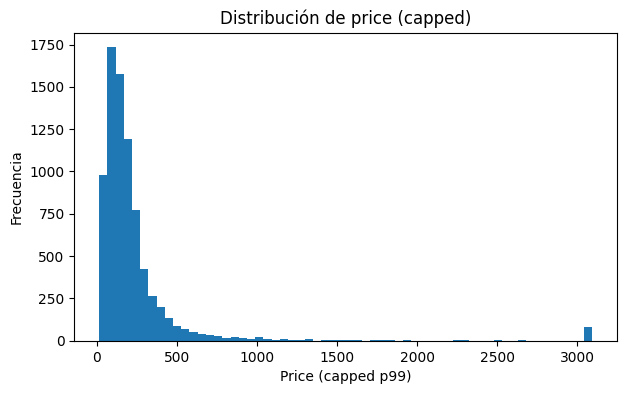

In [ ]:
# Histograma de precio (capped)
plt.figure(figsize=(7,4))
plt.hist(df_clean['price_capped'], bins=60)
plt.xlabel('Price (capped p99)')
plt.ylabel('Frecuencia')
plt.title('Distribución de price (capped)')
plt.show()

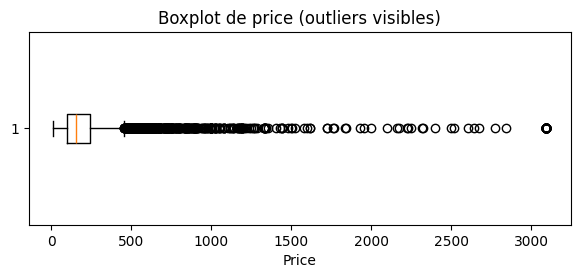

In [ ]:
# Boxplot de price (sin especificar colores)
plt.figure(figsize=(7,2.5))
plt.boxplot(df_clean['price_capped'], vert=False)
plt.xlabel('Price')
plt.title('Boxplot de price (outliers visibles)')
plt.show()

No es perfecto, pero se ve mucho mejor que antes.

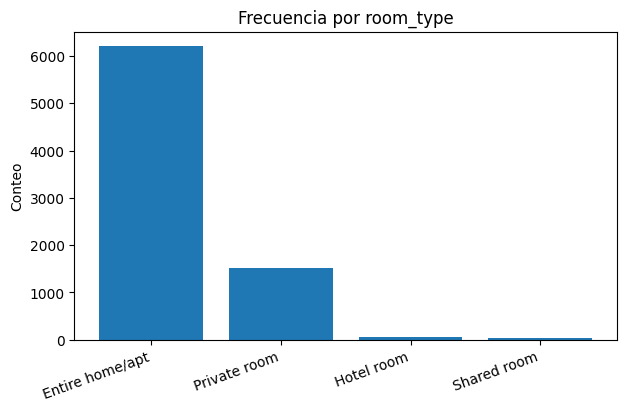

In [ ]:
# Room type (bar)
vc = df_clean['room_type'].value_counts()
plt.figure(figsize=(7,4))
plt.bar(vc.index.astype(str), vc.values)
plt.xticks(rotation=20, ha='right')
plt.ylabel('Conteo')
plt.title('Frecuencia por room_type')
plt.show()

## 7) Análisis bivariado exploratorio


- ¿Cómo varía el **precio** por `room_type`?
- ¿Cómo varía por `neighbourhood_group`?
- Relaciones entre numéricas: correlación simple (Pearson) como *diagnóstico*.


/tmp/ipykernel_30038/284461496.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, vert=True)


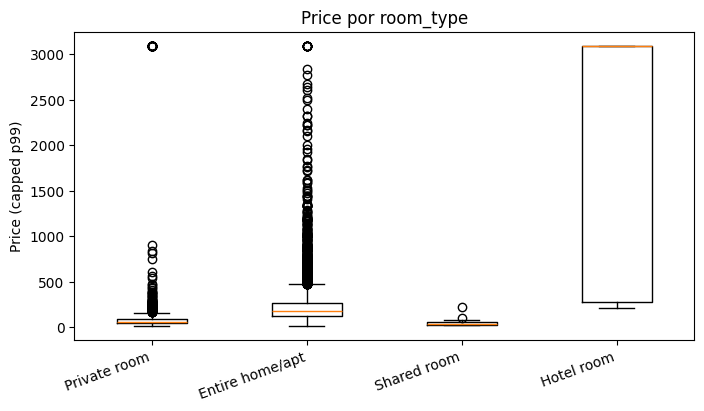

In [ ]:
# Precio por room_type (boxplot)
groups = [df_clean.loc[df_clean['room_type']==rt, 'price_capped'] for rt in df_clean['room_type'].unique()]
labels = list(df_clean['room_type'].unique())

plt.figure(figsize=(8,4))
plt.boxplot(groups, labels=labels, vert=True)
plt.xticks(rotation=20, ha='right')
plt.ylabel('Price (capped p99)')
plt.title('Price por room_type')
plt.show()

In [ ]:
# Precio promedio por neighbourhood_group (top 10 por conteo)
top_ng = df_clean['neighbourhood_group'].value_counts().head(10).index
tmp = df_clean[df_clean['neighbourhood_group'].isin(top_ng)].groupby('neighbourhood_group')['price_capped'].agg(['count','median','mean']).sort_values('count', ascending=False)
tmp

,count,median,mean
neighbourhood_group,,,


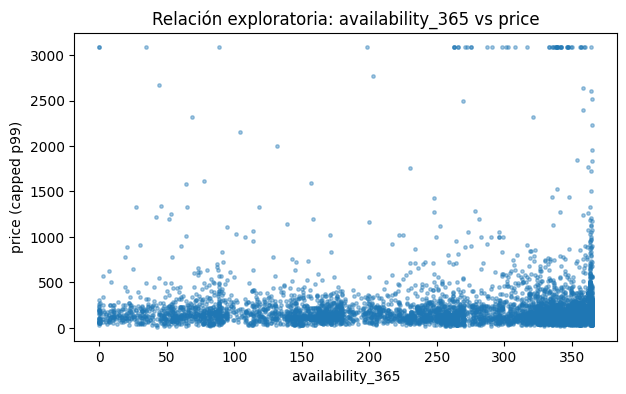

In [ ]:
#Relación entre las variables
# Scatter: price vs availability (muestra aleatoria para velocidad)
sample = df_clean.sample(n=min(5000, len(df_clean)), random_state=7)

plt.figure(figsize=(7,4))
plt.scatter(sample['availability_365'], sample['price_capped'], s=6, alpha=0.4)
plt.xlabel('availability_365')
plt.ylabel('price (capped p99)')
plt.title('Relación exploratoria: availability_365 vs price')
plt.show()

**¿Creen que hay relación entre estas variables?**

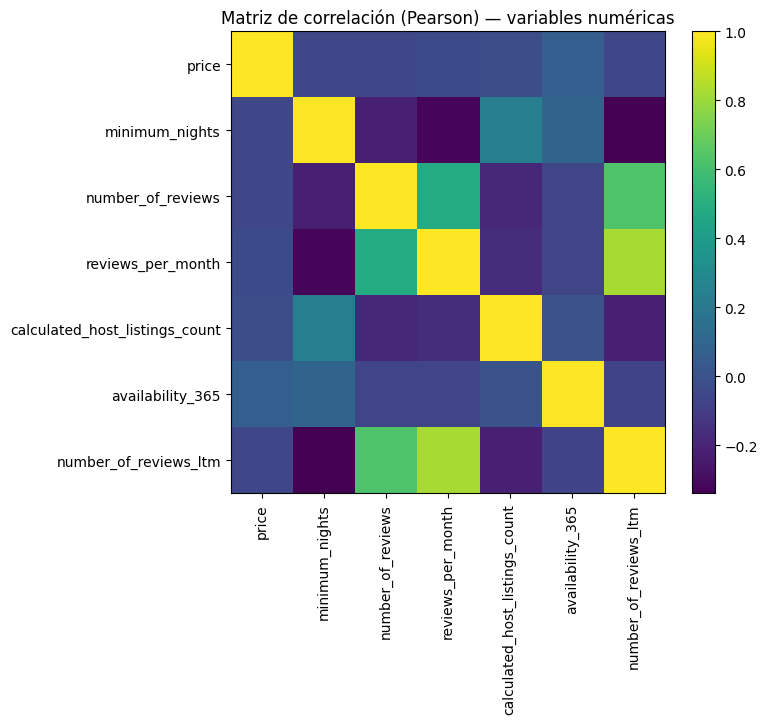

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
price,1.000000,-0.053522,-0.052355,-0.036789,-0.019178,0.059859,-0.054667
minimum_nights,-0.053522,1.000000,-0.222112,-0.317501,0.234609,0.090046,-0.340168
number_of_reviews,-0.052355,-0.222112,1.000000,0.486229,-0.189584,-0.060813,0.632206
reviews_per_month,-0.036789,-0.317501,0.486229,1.000000,-0.163756,-0.058611,0.824059
calculated_host_listings_count,-0.019178,0.234609,-0.189584,-0.163756,1.000000,0.001013,-0.222821
availability_365,0.059859,0.090046,-0.060813,-0.058611,0.001013,1.000000,-0.067032
number_of_reviews_ltm,-0.054667,-0.340168,0.632206,0.824059,-0.222821,-0.067032,1.000000


In [ ]:
# Correlación entre numéricas (diagnóstico)
corr = df_clean[num_cols].corr(numeric_only=True)

plt.figure(figsize=(7,6))
plt.imshow(corr.values, aspect='auto')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Matriz de correlación (Pearson) — variables numéricas')
plt.colorbar()
plt.show()

corr

**¿Qué opinan de estas relaciones?**

## 8) Dataset final “limpio” para el siguiente paso (ESDA)

Exportamos:
- `df_clean`: solo filas con precio, con columnas `*_capped` listas para cartografía/ESDA,
- y conservamos lat/long para el notebook espacial posterior.

**Importante:** no “botamos” los outliers; los dejamos en `price` y `minimum_nights` y creamos versiones capadas.
Esto es útil en docencia porque permite comparar enfoques.


In [ ]:
import os
from google.colab import files

# Selección de columnas recomendada (incluye coordenadas)
keep_cols = [
    'id','host_id','neighbourhood_group','neighbourhood','room_type',
    'latitude','longitude',
    'price','price_capped',
    'minimum_nights','minimum_nights_capped',
    'number_of_reviews','number_of_reviews_ltm','reviews_per_month',
    'calculated_host_listings_count','availability_365',
    'last_review','license'
]

df_out = df_clean[keep_cols].copy()

# Ruta compatible con Colab
out_dir = "/content/resultados"
os.makedirs(out_dir, exist_ok=True)

out_path = f"{out_dir}/airbnb_lisboa_clean.csv"
df_out.to_csv(out_path, index=False)

files.download(out_path)

out_path, df_out.shape

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

('/content/resultados/airbnb_lisboa_clean.csv', (7828, 18))